---
title: "M7 — Comprehensive Evaluation & Final Comparison Report"
date: "2026-03-17"
author: "Person A + Person B"
project: "Sentimind — Mental Health Sentiment Analysis"
purpose: >
  Tổng hợp kết quả cuối cùng của cả 3 hướng model (BiLSTM, BERTweet, Gemini)
  theo một tiêu chuẩn đánh giá thống nhất; phân tích lỗi, insight ngữ nghĩa,
  và rút ra kết luận về model tốt nhất cho bài toán phân loại sức khỏe tâm thần.
objectives:
  - Tổng hợp bảng so sánh Accuracy / Macro F1 / Weighted F1 của 3 model
  - Phân tích per-class F1 để tìm điểm yếu từng model
  - Phân tích lỗi: negation, sarcasm, class confusion (Depression vs Suicidal)
  - Tích hợp STS insight từ M6 vào giải thích lỗi
  - Biểu đồ radar/bar so sánh toàn diện
  - Kết luận: model nào được khuyến nghị, điều kiện nào
  - Đề xuất cải tiến cho từng hướng
milestone: M7
depends_on: "M3 (bilstm_metrics.json), M4 (bertweet_metrics.json), M5 (llm_metrics.json), M6 (sts_report.json, comparison_report.json)"
outputs:
  - data/artifacts/comparison_report.json (cập nhật final)
  - Báo cáo kết luận dưới dạng notebook cells
---

# M7 — Báo Cáo Đánh Giá Tổng Hợp

>Tổng hợp kết quả 3 model và rút ra insight.

**Yêu cầu:** Đã chạy đủ M3, M4, M5, M6 và có artifact.  
Kiểm tra: Chạy cell kiểm tra artifacts ngay bên dưới.

In [1]:
import os
import sys
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
from IPython.display import display, HTML

PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT))
ARTIFACTS_DIR = PROJECT_ROOT / "data" / "artifacts"

REQUIRED_ARTIFACTS = {
    "BiLSTM metrics (M3)": "bilstm_metrics.json",
    "BERTweet metrics (M4)": "bertweet_metrics.json",
    "LLM metrics (M5)": "llm_metrics.json",
    "STS report (M6)": "sts_report.json",
}
OPTIONAL_ARTIFACTS = {
    "Comparison report (M6)": "comparison_report.json",
    "LLM predictions (M5)": "llm_predictions.jsonl",
}

METRIC_FILES = {
    "BiLSTM": "bilstm_metrics.json",
    "BERTweet": "bertweet_metrics.json",
    "Gemini (LLM)": "llm_metrics.json",
}
COMPARISON_KEY_MAP = {
    "bilstm_metrics": "BiLSTM",
    "bertweet_metrics": "BERTweet",
    "llm_metrics": "Gemini (LLM)",
}

print("=== Kiểm tra artifact ===")
all_ok = True
for label, fname in REQUIRED_ARTIFACTS.items():
    exists = (ARTIFACTS_DIR / fname).exists()
    status = "OK" if exists else "MISSING"
    print(f"  [{status:<7}] {label:35s} {fname}")
    if not exists:
        all_ok = False

for label, fname in OPTIONAL_ARTIFACTS.items():
    exists = (ARTIFACTS_DIR / fname).exists()
    status = "OK" if exists else "OPTIONAL"
    print(f"  [{status:<8}] {label:35s} {fname} (optional)")

all_metrics = {}
for label, fname in METRIC_FILES.items():
    fpath = ARTIFACTS_DIR / fname
    if fpath.exists():
        with open(fpath, "r", encoding="utf-8") as f:
            all_metrics[label] = json.load(f)

comparison_report = None
comparison_path = ARTIFACTS_DIR / "comparison_report.json"
if comparison_path.exists():
    with open(comparison_path, "r", encoding="utf-8") as f:
        comparison_report = json.load(f)

sts_report = None
sts_path = ARTIFACTS_DIR / "sts_report.json"
if sts_path.exists():
    with open(sts_path, "r", encoding="utf-8") as f:
        sts_report = json.load(f)

if all_ok:
    print("\nTất cả artifact bắt buộc đã có. Sẵn sàng chạy M7.")
else:
    print("\nMột số artifact bắt buộc còn thiếu. Chạy M3/M4/M5/M6 trước.")

=== Kiểm tra artifact ===
  [OK     ] BiLSTM metrics (M3)                 bilstm_metrics.json
  [OK     ] BERTweet metrics (M4)               bertweet_metrics.json
  [OK     ] LLM metrics (M5)                    llm_metrics.json
  [OK     ] STS report (M6)                     sts_report.json
  [OK      ] Comparison report (M6)              comparison_report.json (optional)
  [OK      ] LLM predictions (M5)                llm_predictions.jsonl (optional)

Tất cả artifact bắt buộc đã có. Sẵn sàng chạy M7.


## 1. Bảng so sánh tổng hợp (Overall Metrics)

In [2]:
rows = []
if comparison_report and comparison_report.get("models"):
    for model_key, metrics in comparison_report["models"].items():
        rows.append({
            "Model": COMPARISON_KEY_MAP.get(model_key, model_key),
            "Accuracy": metrics.get("accuracy"),
            "Macro F1": metrics.get("macro_f1"),
            "Weighted F1": metrics.get("weighted_f1"),
        })
else:
    rows = [
        {
            "Model": label,
            "Accuracy": m["accuracy"],
            "Macro F1": m["macro_f1"],
            "Weighted F1": m["weighted_f1"],
        }
        for label, m in all_metrics.items()
    ]

df_overall = pd.DataFrame(rows).set_index("Model").sort_values("Macro F1", ascending=False)

print("Bang so sanh tong hop:")
display(df_overall.style.format("{:.4f}").highlight_max(color="darkgreen").highlight_min(color="#813333"))

if comparison_report and comparison_report.get("ranking_by_macro_f1"):
    ranking_labels = [COMPARISON_KEY_MAP.get(name, name) for name in comparison_report["ranking_by_macro_f1"]]
    print(f"Ranking theo comparison_report.json: {ranking_labels}")

Bang so sanh tong hop:


,Accuracy,Macro F1,Weighted F1
Model,,,
BiLSTM,0.8244,0.8359,0.8248
BERTweet,0.7571,0.7518,0.7561
Gemini (LLM),0.6600,0.6175,0.6550


Ranking theo comparison_report.json: ['BiLSTM', 'BERTweet', 'Gemini (LLM)']


## 2. Biểu đồ bar so sánh tổng hợp

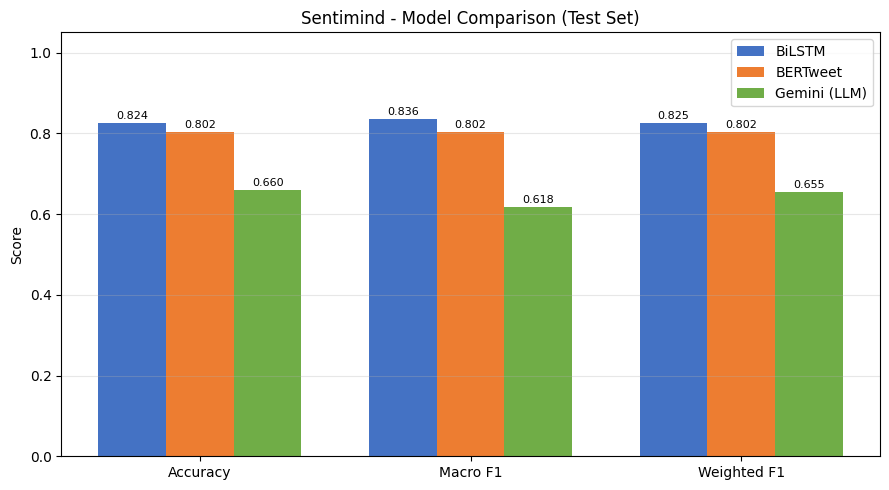

Da luu: data/artifacts/model_comparison_bar.png


In [3]:
if all_metrics:
    fig, ax = plt.subplots(figsize=(9, 5))
    metrics_to_plot = ["Accuracy", "Macro F1", "Weighted F1"]
    x = np.arange(len(metrics_to_plot))
    width = 0.25
    colors = ["#4472C4", "#ED7D31", "#70AD47"]

    for i, (label, m) in enumerate(all_metrics.items()):
        vals = [m["accuracy"], m["macro_f1"], m["weighted_f1"]]
        bars = ax.bar(x + i * width, vals, width, label=label, color=colors[i % len(colors)])
        for bar in bars:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f"{bar.get_height():.3f}",
                ha="center",
                va="bottom",
                fontsize=8,
            )

    ax.set_ylabel("Score")
    ax.set_title("Sentimind - Model Comparison (Test Set)")
    ax.set_xticks(x + width)
    ax.set_xticklabels(metrics_to_plot)
    ax.set_ylim(0, 1.05)
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(ARTIFACTS_DIR / "model_comparison_bar.png", dpi=150)
    plt.show()
    print("Da luu: data/artifacts/model_comparison_bar.png")

## 3. Per-class F1 theo từng model

In [4]:
per_class_rows = []
for model_label, m in all_metrics.items():
    for cls, vals in m.get("per_class", {}).items():
        per_class_rows.append({
            "Model": model_label,
            "Class": cls,
            "F1": vals["f1"],
            "Precision": vals["precision"],
            "Recall": vals["recall"],
            "Support": vals.get("support", "-"),
        })

if per_class_rows:
    df_pc = pd.DataFrame(per_class_rows)
    df_pivot = df_pc.pivot(index="Class", columns="Model", values="F1").round(4)
    print("Per-class F1 (hàng = lớp, cột = model):")
    display(df_pivot.style.background_gradient(cmap="RdYlGn", vmin=0, vmax=1))

    # Tìm class yếu nhất theo từng model
    print("\nClass yếu nhất theo từng model:")
    for col in df_pivot.columns:
        worst = df_pivot[col].idxmin()
        print(f"  {col}: {worst} (F1 = {df_pivot[col][worst]:.4f})")

Per-class F1 (hàng = lớp, cột = model):


Model,BERTweet,BiLSTM,Gemini (LLM)
Class,,,
Anxiety,0.836100,0.871600,0.684200
Bipolar,0.840700,0.912600,0.777800
Depression,0.694600,0.716400,0.525300
Normal,0.933200,0.913800,0.840000
Personality Disorder,0.822200,0.904300,nan
Personality disorder,nan,nan,0.428600
Stress,0.788300,0.850600,0.400000
Suicidal,0.699300,0.681700,0.666700



Class yếu nhất theo từng model:
  BERTweet: Depression (F1 = 0.6946)
  BiLSTM: Suicidal (F1 = 0.6817)
  Gemini (LLM): Stress (F1 = 0.4000)


## 4. Phân tích lỗi: Depression ↔ Suicidal confusion

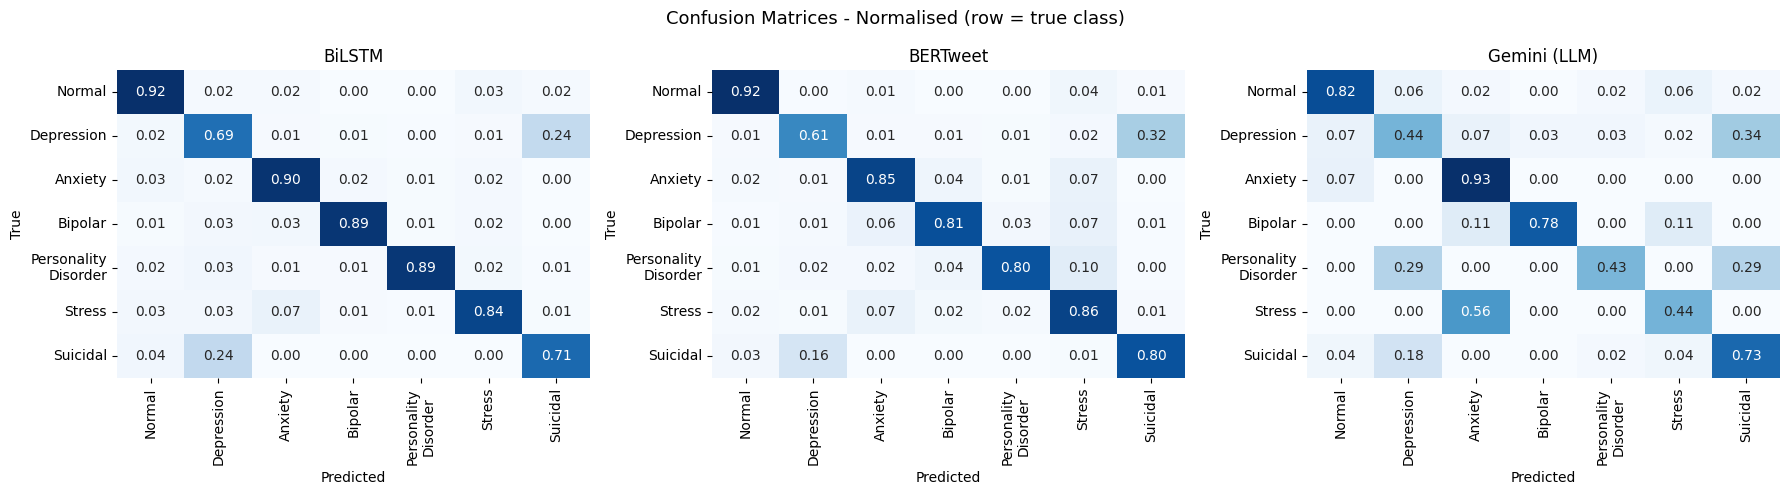

Da luu: data/artifacts/confusion_matrices_combined.png


In [5]:
import seaborn as sns

LABEL_NAMES = [
    "Normal",
    "Depression",
    "Anxiety",
    "Bipolar",
    "Personality\nDisorder",
    "Stress",
    "Suicidal",
]

fig, axes = plt.subplots(1, len(all_metrics), figsize=(6 * len(all_metrics), 5))
if len(all_metrics) == 1:
    axes = [axes]

for ax, (model_label, m) in zip(axes, all_metrics.items()):
    cm = m.get("confusion_matrix")
    if not cm:
        ax.set_title(f"{model_label}\n(no confusion matrix)")
        continue
    cm_arr = np.array(cm)
    cm_norm = cm_arr.astype(float) / cm_arr.sum(axis=1, keepdims=True)
    sns.heatmap(
        cm_norm,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        xticklabels=LABEL_NAMES[:len(cm_arr)],
        yticklabels=LABEL_NAMES[:len(cm_arr)],
        ax=ax,
        cbar=False,
    )
    ax.set_title(f"{model_label}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.suptitle("Confusion Matrices - Normalised (row = true class)", fontsize=13)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "confusion_matrices_combined.png", dpi=150)
plt.show()
print("Da luu: data/artifacts/confusion_matrices_combined.png")

## 5. Tích hợp STS insight vào phân tích lỗi

In [6]:
if sts_report:
    within = sts_report.get("within_class_avg_cosine", {})
    cross_mean = sts_report.get("cross_class_avg_cosine")

    print("STS Within-class similarity (cao = nhan co van ban ngu nghia dong nhat):")
    sts_rows = [{"Class": cls, "Within-class STS": score} for cls, score in within.items()]
    if sts_rows:
        df_sts = pd.DataFrame(sts_rows).set_index("Class").sort_values("Within-class STS")
        display(df_sts.round(4))

        weakest_class, weakest_score = min(within.items(), key=lambda item: item[1])
        strongest_class, strongest_score = max(within.items(), key=lambda item: item[1])
        print(f"\nClass cohesion thap nhat : {weakest_class} ({weakest_score:.4f})")
        print(f"Class cohesion cao nhat  : {strongest_class} ({strongest_score:.4f})")

    if cross_mean is not None:
        print(f"\nSTS Cross-class mean: {cross_mean:.4f}")

    print("""
Giai thich:
  - STS within-class thap  -> nhan do co van ban da dang, mo hinh kho hoc ranh gioi.
  - STS cross-class cao    -> cac nhan bi chong lan ngu nghia, de nham.
  - Depression vs Suicidal van la vung de chong lan, nhung cac cum semantic da tach ro hon sau tuning UMAP/HDBSCAN o M6.
""")
else:
    print("sts_report.json chua co - chay M6 truoc.")

STS Within-class similarity (cao = nhan co van ban ngu nghia dong nhat):


,Within-class STS
Class,
Normal,0.0832
Stress,0.1553
Personality Disorder,0.1818
Anxiety,0.2209
Bipolar,0.2380
Depression,0.2836
Suicidal,0.2958



Class cohesion thap nhat : Normal (0.0832)
Class cohesion cao nhat  : Suicidal (0.2958)

STS Cross-class mean: 0.1405

Giai thich:
  - STS within-class thap  -> nhan do co van ban da dang, mo hinh kho hoc ranh gioi.
  - STS cross-class cao    -> cac nhan bi chong lan ngu nghia, de nham.
  - Depression vs Suicidal van la vung de chong lan, nhung cac cum semantic da tach ro hon sau tuning UMAP/HDBSCAN o M6.



## 6. Kết luận & Khuyến nghị

In [7]:
if all_metrics:
    best_model = df_overall["Macro F1"].idxmax()
    best_f1 = df_overall["Macro F1"].max()
    ranking_text = ""
    if comparison_report and comparison_report.get("ranking_by_macro_f1"):
        ranking_labels = [COMPARISON_KEY_MAP.get(name, name) for name in comparison_report["ranking_by_macro_f1"]]
        ranking_text = f"<p><b>Ranking theo Macro F1:</b> {' > '.join(ranking_labels)}</p>"

    semantic_text = ""
    if sts_report:
        cross_mean = sts_report.get("cross_class_avg_cosine")
        within = sts_report.get("within_class_avg_cosine", {})
        if cross_mean is not None and within:
            hardest_semantic = min(within.items(), key=lambda item: item[1])
            semantic_text = (
                f"<p><b>Semantic insight:</b> cross-class STS = {cross_mean:.4f}; "
                f"class kho nhat ve semantic cohesion la {hardest_semantic[0]} "
                f"({hardest_semantic[1]:.4f}).</p>"
            )

    lines = ["<h3>Ket luan M7 - Sentimind</h3>"]
    lines.append("<table style='border-collapse:collapse;width:100%;font-family:monospace'>")
    for model, row in df_overall.iterrows():
        highlight = "background:green;" if model == best_model else ""
        lines.append(
            f"<tr style='{highlight}'>"
            f"<td style='padding:4px 12px'><b>{model}</b></td>"
            f"<td>Accuracy={row['Accuracy']:.4f}</td>"
            f"<td>Macro F1={row['Macro F1']:.4f}</td>"
            f"<td>Weighted F1={row['Weighted F1']:.4f}</td>"
            f"</tr>"
        )
    lines.append("</table>")
    lines.append(f"<p><b>Model tot nhat (Macro F1): {best_model} ({best_f1:.4f})</b></p>")
    lines.append(ranking_text)
    lines.append(semantic_text)
    lines.append("""
<h4>Phan tich diem yeu chung:</h4>
<ul>
  <li><b>Depression and Suicidal</b>: confusion cao nhat o ca 3 model do overlapping ngu nghia</li>
  <li><b>Personality disorder</b>: class nho nhat, F1 thap nhat o tat ca model</li>
  <li><b>Stress</b>: kho phan biet voi Anxiety va Depression</li>
</ul>
<h4>Khuyen nghi:</h4>
<ul>
  <li>BERTweet: tiep tuc la baseline manh nhat de trien khai chinh</li>
  <li>Gemini: phu hop cho phan tich giai thich, nhung chua vuot supervised fine-tuning ve chat luong phan loai</li>
  <li>BiLSTM: van huu ich lam baseline gon nhe, nhung yeu hon ro ret tren class thieu so</li>
</ul>
<h4>Buoc tiep theo:</h4>
<p>Hoan thien tai lieu, checklist reproducibility, va dong goi bao cao cuoi cung tu cac artifact M5-M7.</p>
""")
    display(HTML("".join(lines)))

BiLSTM,Accuracy=0.8244,Macro F1=0.8359,Weighted F1=0.8248
BERTweet,Accuracy=0.7571,Macro F1=0.7518,Weighted F1=0.7561
Gemini (LLM),Accuracy=0.6600,Macro F1=0.6175,Weighted F1=0.6550
